### Web Browsing Agent

Core capability:
- Opens a real headless Chromium browser
- Navigates to actual websites
- Reads and extracts content from pages
- Reports back what it found

Tools available to the agent:
- navigate_browser — go to any URL
- extract_text — extract text from current page
- extract_hyperlinks — get all links on a page
- get_elements — find specific elements on a page
- click_element — click buttons or links
- current_webpage — check what page it's on
- previous_webpage — go back

In [1]:
# Import the necessary libraries
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from sendgrid import SendGridAPIClient
from sendgrid.helpers.mail import Mail
from dotenv import load_dotenv
from IPython.display import display, Image
import requests
import gradio as gr
import os

In [2]:
# Load environment variables
load_dotenv(override=True)

True

In [3]:
# Define the State object
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [4]:
# SendGrid email tool
sendgrid_api_key = os.getenv("SENDGRID_API_KEY")
sendgrid_from_email = os.getenv("SENDGRID_FROM_EMAIL")
sendgrid_to_email = os.getenv("SENDGRID_TO_EMAIL")

@tool
def send_digest(content: str) -> str:
    """Send the news digest to the user via email using SendGrid"""
    try:
        mail = Mail(
            from_email=sendgrid_from_email,
            to_emails=sendgrid_to_email,
            subject="Your Daily Business & Finance Digest",
            plain_text_content=content
        )
        sg = SendGridAPIClient(sendgrid_api_key)
        response = sg.send(mail)
        return f"Digest emailed successfully! Status: {response.status_code}"
    except Exception as e:
        print(f"Error: {str(e)}")
        return f"Failed to send digest: {str(e)}"

In [5]:
# Introducing nest_asyncio
import nest_asyncio
nest_asyncio.apply()

In [6]:
# Set up a Web Browsing Agent
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser

/tmp/ipykernel_20109/2847294277.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.agent_toolkits import PlayWrightBrowserToolkit


In [7]:
from playwright.async_api import async_playwright

playwright = await async_playwright().start()
async_browser = await playwright.chromium.launch(
    headless=True,
    args=["--no-sandbox", "--disable-dev-shm-usage"]
)

toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()
print("Tools loaded:", [t.name for t in tools])

Tools loaded: ['click_element', 'navigate_browser', 'previous_webpage', 'extract_text', 'extract_hyperlinks', 'get_elements', 'current_webpage']


In [8]:
# Build tool dict
tool_dict = {tool.name: tool for tool in tools}
navigate_tool = tool_dict.get("navigate_browser")

# Navigate to CNN
await navigate_tool.arun({"url": "https://www.bbc.com/news"})

# Extract text directly via Playwright (bypassing extract_text tool)
page = async_browser.contexts[0].pages[0]
content = await page.text_content("body")
print(content[:2000])

<style>.hide-when-no-script { visibility: hidden; }</style>Skip to contentBritish Broadcasting CorporationRegisterSign InHomeNewsFootball 2026SportBusinessTechnologyHealthCultureArtsTravelEarthAudioVideoLiveUS & CanadaUKAfricaAsiaAustraliaEuropeLatin AmericaMiddle EastIn PicturesBBC InDepthBBC Verify<details class="NoJsNavigation-styles__NoJsMenuStyled-sc-a2077f0f-0 gWJlXk"><summary class="NoJsNavigation-styles__NoJsSummaryStyled-sc-a2077f0f-2 iPrFaU"><svg viewBox="0 0 32 32" width="20" height="20" category="actions" icon="list-view-text" class="Icon-styles__IconStyled-sc-4d91d42a-0 iosMJz"><path d="M1 7.5h30V1.9H1v5.6zm0 22.6h30v-5.6H1v5.6zm0-11.3h30v-5.6H1v5.6z"></path></svg></summary><ul class="NoJsNavigation-styles__NoJsListStyled-sc-a2077f0f-1 dlnaUh"><li class="NoJsNavigation-styles__NoJsListItemStyled-sc-a2077f0f-3 hKbVLW"><a href="/home" class="Navigation-styles__MainNavigationLink-sc-f1c1fa10-4 gkFqwf">Home</a></li><ul class="NoJsNavigation-styles__NoJsListStyled-sc-a2077f0f-1

In [13]:
# Extract only visible text, skip HTML tags
content = await page.evaluate("document.body.innerText")
import textwrap
print(textwrap.fill(content[:3000]))

Skip to content Register Sign In Home News Football 2026 Sport
Business Technology Health Culture Arts Travel Earth Audio Video Live
US & Canada UK Africa Asia Australia Europe Latin America Middle East
In Pictures BBC InDepth BBC Verify Rescuers search rubble for
survivors as Venezuela earthquakes kill at least 235  At least 4,300
people have been injured after two seven-plus magnitude shallow quakes
hit seconds apart.  40 mins ago Latin America Prayers and relief
efforts after Venezuela's earthquakes  The BBC's Vanessa Silva reports
from Caracas as the city faces the aftermath of back-to-back tremors.
2 hrs ago Latin America A Chinese box office hit sparks a debate about
identity in Singapore  A nostalgic tale about family, hope and
hardship has opened an unexpected conversation.  6 hrs ago Asia LIVE
Australia move into last 32 with draw against Paraguay - reaction
Follow live updates as Paraguay take on Australia in Group D of the
FIFA World Cup.  King Charles reveals he paid £12.9m

In [16]:
# Combine the tools + LLM
all_tools = tools + [send_digest]

llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(all_tools)

In [17]:
# Chatbot function
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

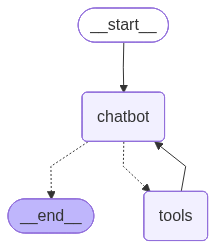

In [19]:
# Start Graph Builder with State class
graph_builder = StateGraph(State)

# Create Node
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=all_tools))

# Create edges
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")

memory = MemorySaver()

# Compile the graph
graph = graph_builder.compile(checkpointer=memory)

# Visualize the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
# Thread ID for Memory
config = {"configurable": {"thread_id": "20"}}

async def chat(user_input: str, history):
    result = await graph.ainvoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content

gr.ChatInterface(chat).launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://d2ada57d0db7aa94b2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/python/3.12.1/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/python/3.12.1/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/python/3.12.1/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/python/3.12.1/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_help